# Comparaison 6 modèles — Dataset 1 Pump Maintenance — by_pump_id

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_pump_id : Pump 1 → Pump 2 → Pump 3 → Pump 4 → Pump 5 (5 tâches) |
| **Modèles** | TinyOL · EWC · HDC · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | Large_Industrial_Pump_Maintenance_Dataset.csv |
| **Sprint** | 8 — S8-13 |

Ce notebook agrège les résultats des expériences **exp_012, exp_013, exp_014, exp_020, exp_015, exp_021**.
Il constitue le support de présentation principal pour les réunions d'encadrement sur Dataset 1.

**Figures générées** :
1. `radar_comparison.png` — radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `barplot_aa_comparison.png` — barplot AA/AF/BWT pour les 6 modèles
3. `acc_matrix_grid.png` — grille 2×3 des matrices d'accuracy 5×5
4. `performance_by_pump_id_bar.png` — accuracy finale par Pump_ID (spécifique by_pump_id)
5. `scatter_ram_vs_accuracy.png` — trade-off RAM/performance (Gap 2, budget STM32 ≤ 64 Ko)
6. `scatter_flops_vs_accuracy.png` — coût de calcul portable (MACs, indépendant de la machine)
7. `scatter_latency_vs_accuracy.png` — latence PC (budget 100 ms, ⚠ non transférable au MCU)

In [51]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "pump_by_pump_id":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar, save_figure,
    plot_performance_by_pump_id_bar,
)
from src.evaluation.compute_cost import compute_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/pump/by_pump_id"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ["Pump 1", "Pump 2", "Pump 3", "Pump 4", "Pump 5"]
MODEL_ORDER = ["TinyOL", "EWC", "HDC", "KMeans", "Mahalanobis", "DBSCAN"]
N_TASKS = 5

MODEL_EXP_MAP = {
    "TinyOL":      ("exp_012_tinyol_pump_by_id",      "metrics.json",               None),
    "EWC":         ("exp_013_ewc_pump_by_id",          "metrics.json",               "acc_matrix_ewc.npy"),
    "HDC":         ("exp_014_hdc_pump_by_id",          "metrics.json",               "acc_matrix_hdc.npy"),
    "KMeans":      ("exp_020_kmeans_pump_by_id",        "metrics_kmeans_dataset1.json",         "acc_matrix_kmeans.npy"),
    "Mahalanobis": ("exp_015_mahalanobis_pump_by_id",  "metrics_mahalanobis_dataset1.json",    "acc_matrix_mahalanobis.npy"),
    "DBSCAN":      ("exp_021_dbscan_pump_by_id",        "metrics_dbscan_dataset1.json",         "acc_matrix_dbscan.npy"),
}

BASE = REPO_ROOT / "experiments"
RAM_LIMIT = 64 * 1024  # bytes — contrainte STM32N6


def normalize_metrics(raw: dict, model_name: str) -> dict:
    """Normalise les différents schémas de metrics.json vers un dict commun.

    Clés retournées : aa, af, bwt, ram_peak_bytes, inference_latency_ms, n_params, auroc_avg.
    """
    if model_name == "TinyOL":
        return {
            "aa":  raw.get("acc_final", raw.get("aa", 0.0)),
            "af":  raw.get("avg_forgetting", raw.get("af", 0.0)),
            "bwt": raw.get("backward_transfer", raw.get("bwt", 0.0)),
            "ram_peak_bytes": raw.get("ram_peak_bytes", 0),
            "inference_latency_ms": raw.get("inference_latency_ms", 0.0),
            "n_params": raw.get("n_params_encoder", 184) + raw.get("n_params_oto", 10),
            "auroc_avg": raw.get("auroc_avg"),
        }
    if model_name == "EWC" and "cl_metrics" in raw:
        cl = raw["cl_metrics"].get("ewc", raw["cl_metrics"])
        mem = raw["cl_metrics"].get("memory", {}).get("forward", {})
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": mem.get("ram_peak_bytes", raw.get("ram_peak_bytes", 0)),
            "inference_latency_ms": mem.get("inference_latency_ms", raw.get("inference_latency_ms", 0.0)),
            "n_params": mem.get("n_params", raw.get("n_params", 0)),
            "auroc_avg": raw.get("auroc_avg"),
        }
    if model_name == "HDC" and "cl_metrics" in raw:
        cl = raw["cl_metrics"]
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": cl.get("ram_peak_bytes", 0),
            "inference_latency_ms": cl.get("inference_latency_ms", 0.0),
            "n_params": cl.get("n_params", 2048),
            "auroc_avg": cl.get("auroc_avg"),
        }
    if "cl_metrics" in raw:  # KMeans structure imbriquée
        cl = raw["cl_metrics"]
        mem = cl.get("memory", {})
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": mem.get("ram_peak_bytes", 0),
            "inference_latency_ms": mem.get("inference_latency_ms", 0.0),
            "n_params": mem.get("n_params", 0),
            "auroc_avg": cl.get("auroc_avg"),
        }
    # Structure plate (Mahalanobis, DBSCAN, EWC/HDC sans cl_metrics)
    return {
        "aa":  raw.get("aa", raw.get("acc_final", 0.0)),
        "af":  raw.get("af", raw.get("avg_forgetting", 0.0)),
        "bwt": raw.get("bwt", raw.get("backward_transfer", 0.0)),
        "ram_peak_bytes": raw.get("ram_peak_bytes", 0),
        "inference_latency_ms": raw.get("inference_latency_ms", 0.0),
        "n_params": raw.get("n_params", 0),
        "auroc_avg": raw.get("auroc_avg"),
    }


def load_acc_matrix(model_name: str, raw: dict, npy_file: str | None, exp_dir: Path) -> np.ndarray:
    """Charge la matrice d'accuracy N×N."""
    if npy_file is not None:
        npy_path = exp_dir / npy_file
        if npy_path.exists():
            return np.array(np.load(npy_path, allow_pickle=True), dtype=float)
    if model_name == "TinyOL" and "acc_matrix" in raw:
        raw_mat = raw["acc_matrix"]
        n = len(raw_mat)
        mat = np.full((n, n), np.nan, dtype=float)
        for i, row in enumerate(raw_mat):
            for j, v in enumerate(row):
                if v is not None:
                    mat[i, j] = v
        return mat
    return np.full((N_TASKS, N_TASKS), np.nan, dtype=float)


# Chargement des 6 modèles (avec fallback mock)
results = {}
acc_matrices = {}

for model in MODEL_ORDER:
    exp_dir_name, metrics_file, npy_file = MODEL_EXP_MAP[model]
    exp_dir = BASE / exp_dir_name / "results"
    m_path = exp_dir / metrics_file
    if m_path.exists():
        raw = json.loads(m_path.read_text())
        results[model] = normalize_metrics(raw, model)
        acc_matrices[model] = load_acc_matrix(model, raw, npy_file, exp_dir)
    else:
        print(f"[MOCK] {model} : {exp_dir_name} non trouvé — valeurs mock utilisées")
        results[model] = {
            "aa": 0.5, "af": 0.0, "bwt": 0.0,
            "ram_peak_bytes": 0, "inference_latency_ms": 0.0,
            "n_params": 0, "auroc_avg": None,
        }
        acc_matrices[model] = np.full((N_TASKS, N_TASKS), 0.5)

    r = results[model]
    auroc_s = f"{r['auroc_avg']:.4f}" if isinstance(r['auroc_avg'], float) else "—"
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms "
          f"n_params={r['n_params']} AUROC={auroc_s}")

print(f"\n6 modèles chargés | Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

TinyOL       → AA=0.5629 AF=0.0071 BWT=-0.0030 RAM=  5.6Ko lat=0.01022ms n_params=1506 AUROC=—
EWC          → AA=0.5658 AF=0.0099 BWT=-0.0099 RAM=  1.1Ko lat=0.03605ms n_params=1377 AUROC=—
HDC          → AA=0.5024 AF=0.0347 BWT=-0.0044 RAM= 14.2Ko lat=0.21829ms n_params=2048 AUROC=—
KMeans       → AA=0.4504 AF=0.0099 BWT=+0.0001 RAM=  5.6Ko lat=0.57246ms n_params=50 AUROC=0.4985
Mahalanobis  → AA=0.4471 AF=0.0150 BWT=+0.0050 RAM=  2.0Ko lat=0.00728ms n_params=650 AUROC=0.4953
DBSCAN       → AA=0.5656 AF=0.0000 BWT=+0.0000 RAM= 48.5Ko lat=0.32627ms n_params=4950 AUROC=0.4519

6 modèles chargés | Date exécution : 2026-04-21 10:09


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/radar_comparison.png


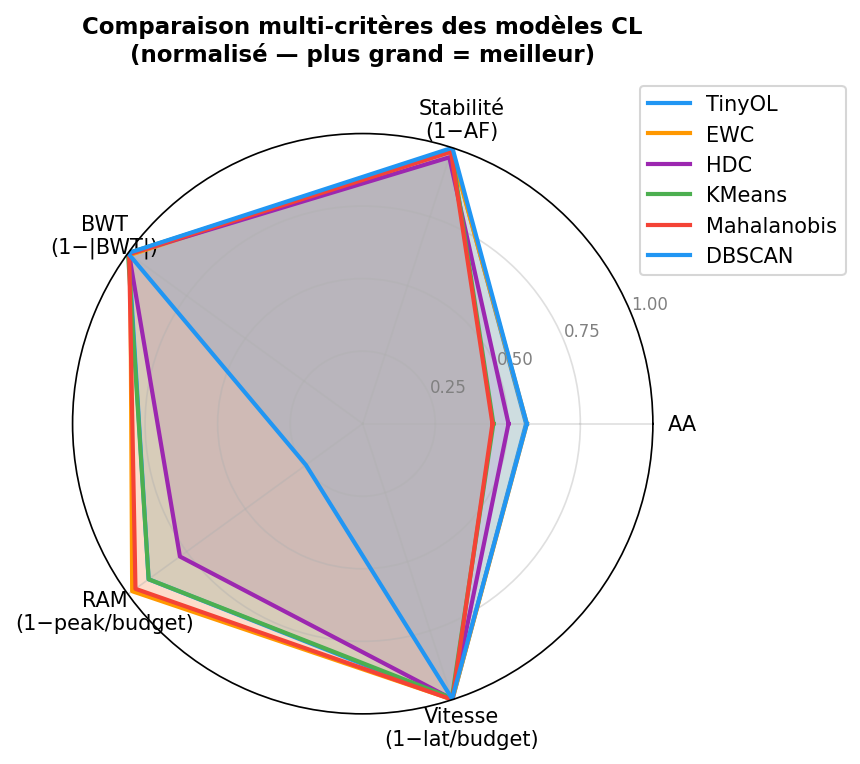

In [52]:
# Section 2 — Radar multi-critères (6 modèles, 5 axes normalisés)
# Axes : AA, Stabilité (1−AF), BWT neutre (1−|BWT|), RAM (1−peak/64Ko), Vitesse (1−lat/100ms)

fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/barplot_aa_comparison.png


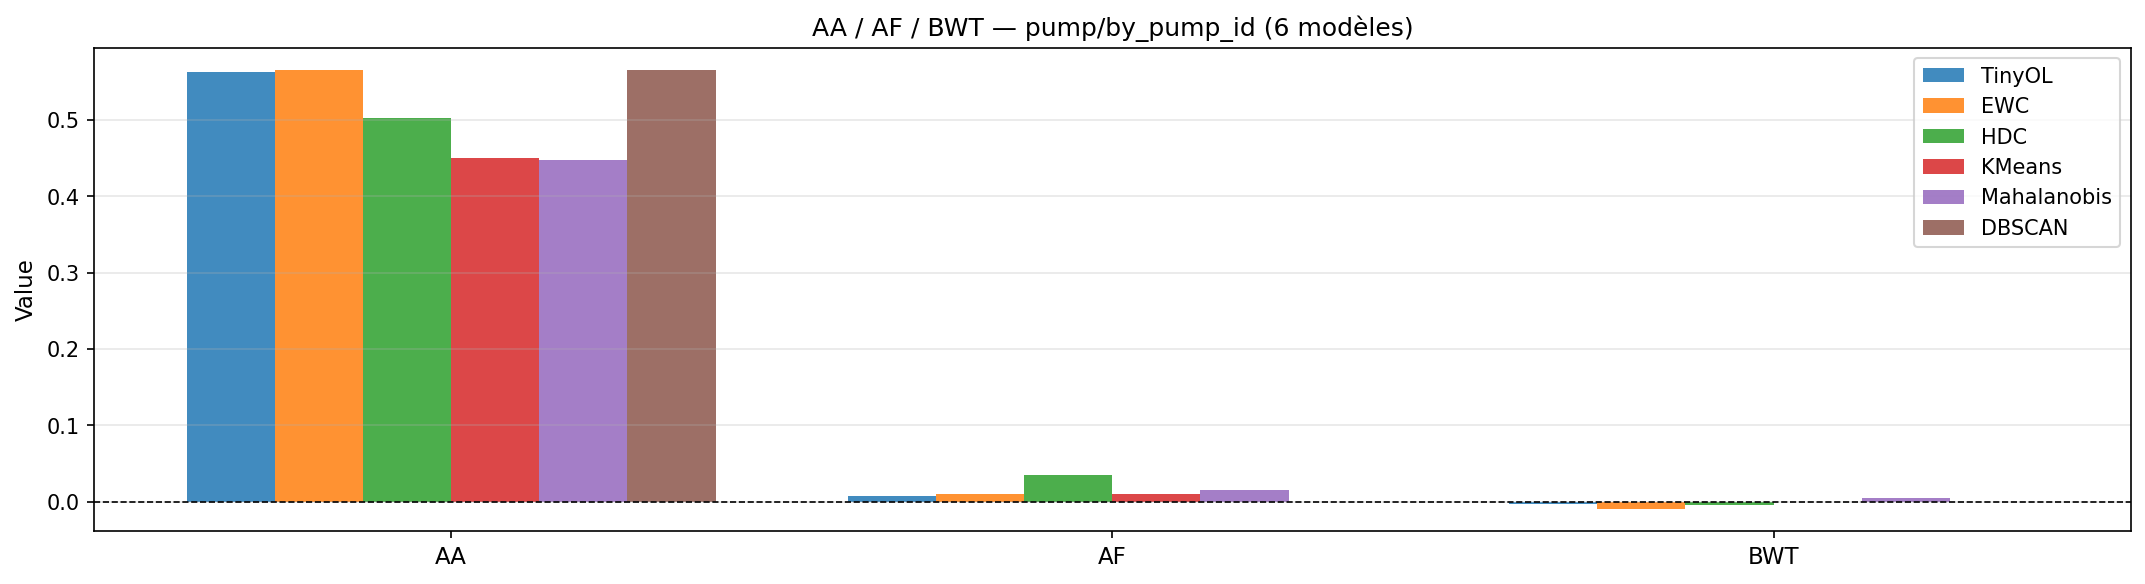

In [53]:
# Section 3 — Barplot AA/AF/BWT groupé (6 modèles)

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — pump/by_pump_id (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "barplot_aa_comparison.png")
display(Image(str(FIGURES_DIR / "barplot_aa_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/acc_matrix_grid.png


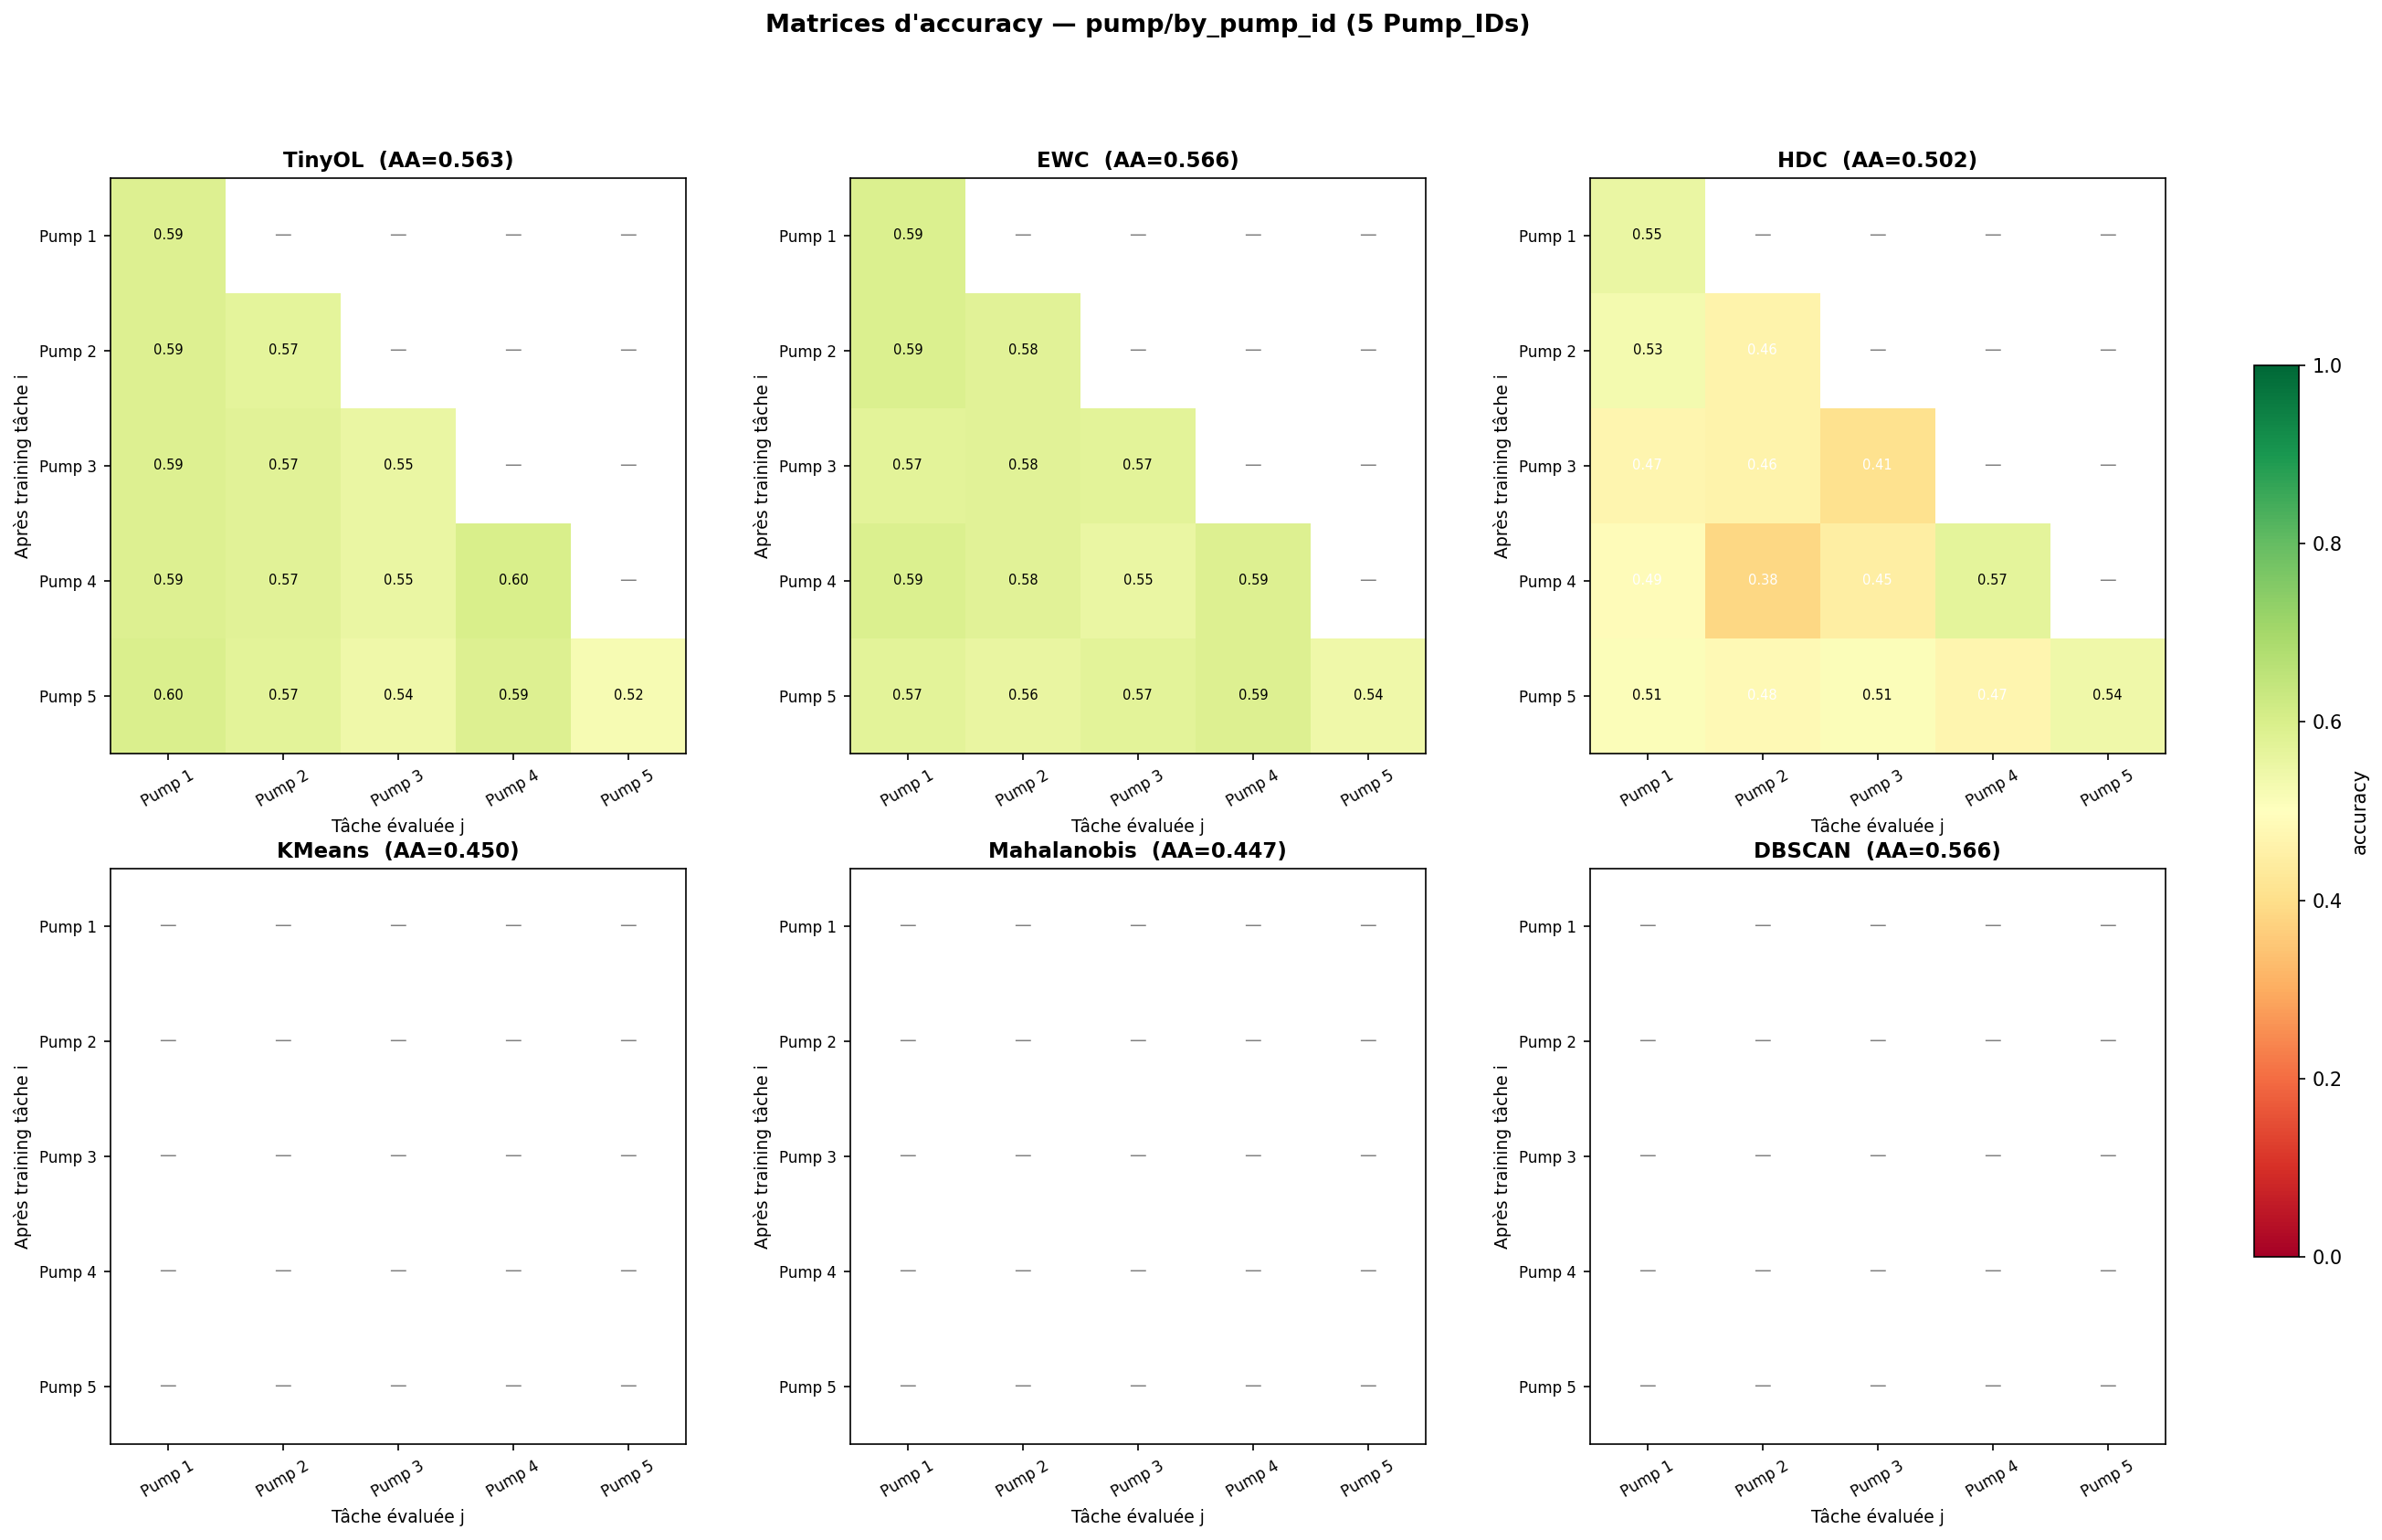

In [54]:
# Section 4 — Grille 2×3 des matrices d'accuracy 5×5 (5 Pump_IDs)

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
cmap = plt.get_cmap("RdYlGn")

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f})", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(TASK_NAMES)))
    ax.set_yticks(range(len(TASK_NAMES)))
    ax.set_xticklabels(TASK_NAMES, rotation=30, fontsize=8)
    ax.set_yticklabels(TASK_NAMES, fontsize=8)
    ax.set_xlabel("Tâche évaluée j", fontsize=9)
    ax.set_ylabel("Après training tâche i", fontsize=9)
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — pump/by_pump_id (5 Pump_IDs)", fontsize=13, fontweight="bold")
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/performance_by_pump_id_bar.png


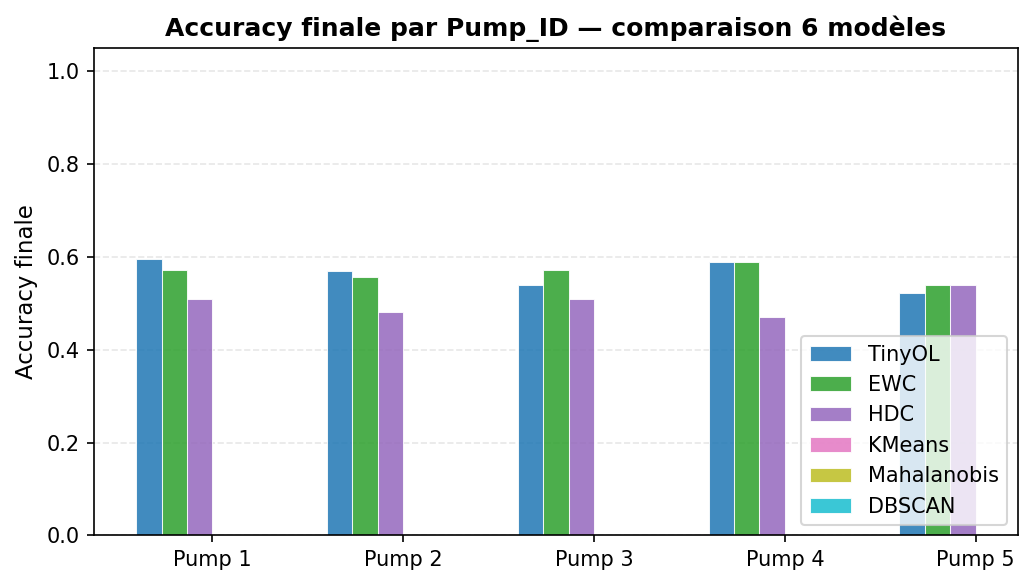

In [55]:
# Section 5 — Performance par Pump_ID (barplot comparaison inter-modèles)
# Spécifique au scénario by_pump_id : accuracy finale (dernière ligne de la matrice) par pompe

results_pump = {
    model: {i + 1: float(mat[-1, i]) for i in range(N_TASKS)}
    for model, mat in acc_matrices.items()
}

fig = plot_performance_by_pump_id_bar(
    results_pump,
    pump_ids=[1, 2, 3, 4, 5],
    title="Accuracy finale par Pump_ID — comparaison 6 modèles",
)
save_figure(fig, FIGURES_DIR / "performance_by_pump_id_bar.png")
display(Image(str(FIGURES_DIR / "performance_by_pump_id_bar.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/scatter_ram_vs_accuracy.png


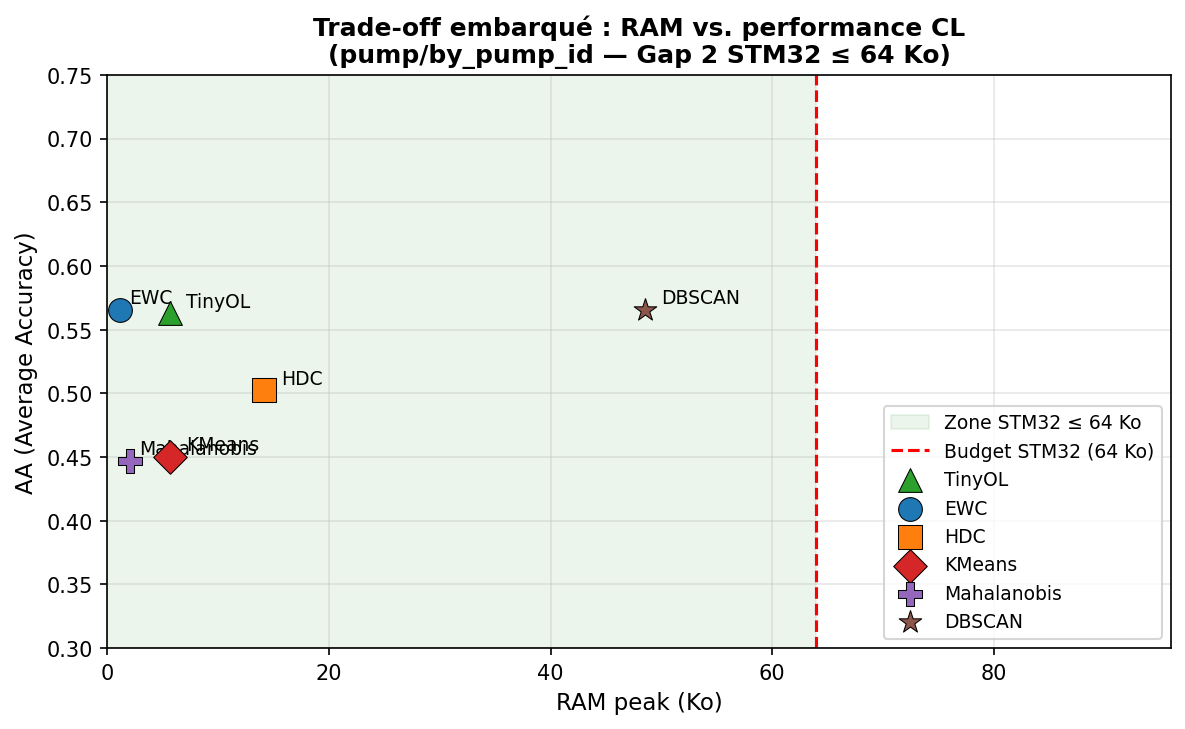

In [56]:
# Section 6a — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# Format cohérent avec notebooks/cl_eval/baselines/pump_single_task.ipynb

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    x_offset = 0.8 if ram_kb < 5 else 1.5
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.005), fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(pump/by_pump_id — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max(max_ram_kb * 1.3, STM32_RAM_LIMIT_KB * 1.5))
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/scatter_flops_vs_accuracy.png


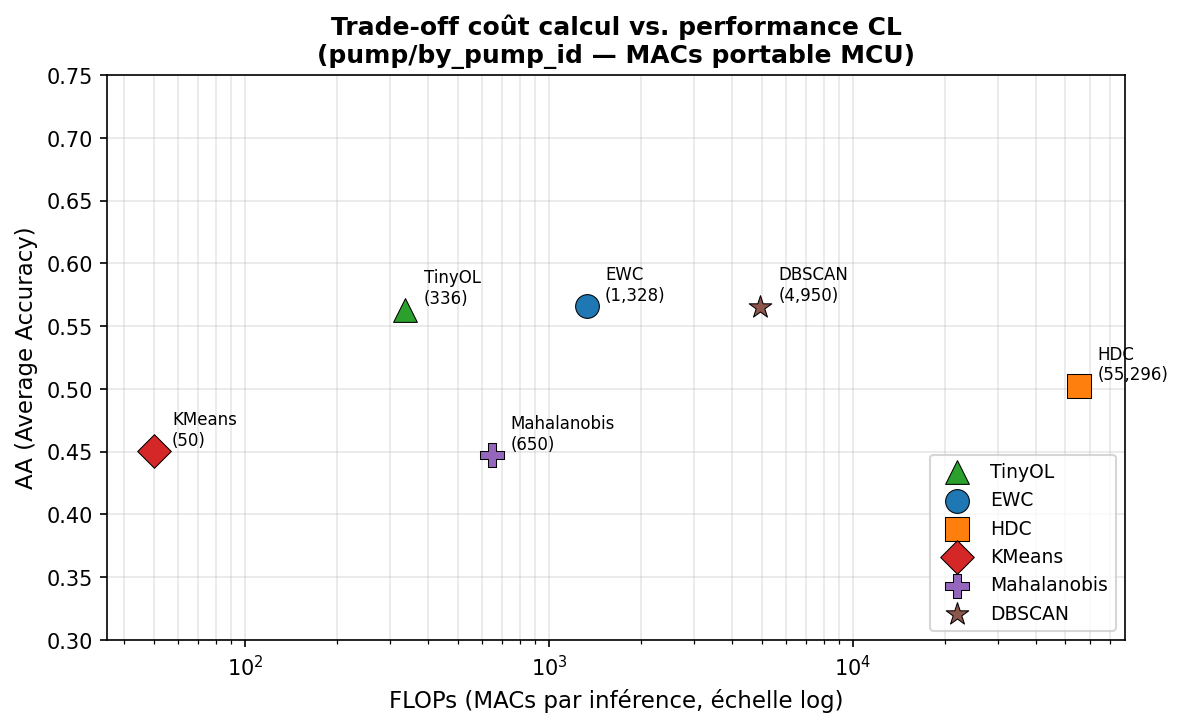

In [58]:
# Section 6b — Scatter FLOPs (MACs) vs. accuracy
# Coût de calcul portable — indépendant de la machine. n_features=25 (stats fenêtrées pump).

kmeans_k = max(1, results["KMeans"]["n_params"] // 25)
dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // 25)

macs = {
    "EWC":         compute_macs("EWC",         n_features=25, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=25, encoder_dims=[8, 8, 8], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=25, dim_hv=2048, n_classes=2),
    "KMeans":      compute_macs("KMeans",      n_features=25, n_clusters=kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=25),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=25, n_core_samples=dbscan_n_core),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.15, acc + 0.005), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(pump/by_pump_id — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_pump_id/scatter_latency_vs_accuracy.png


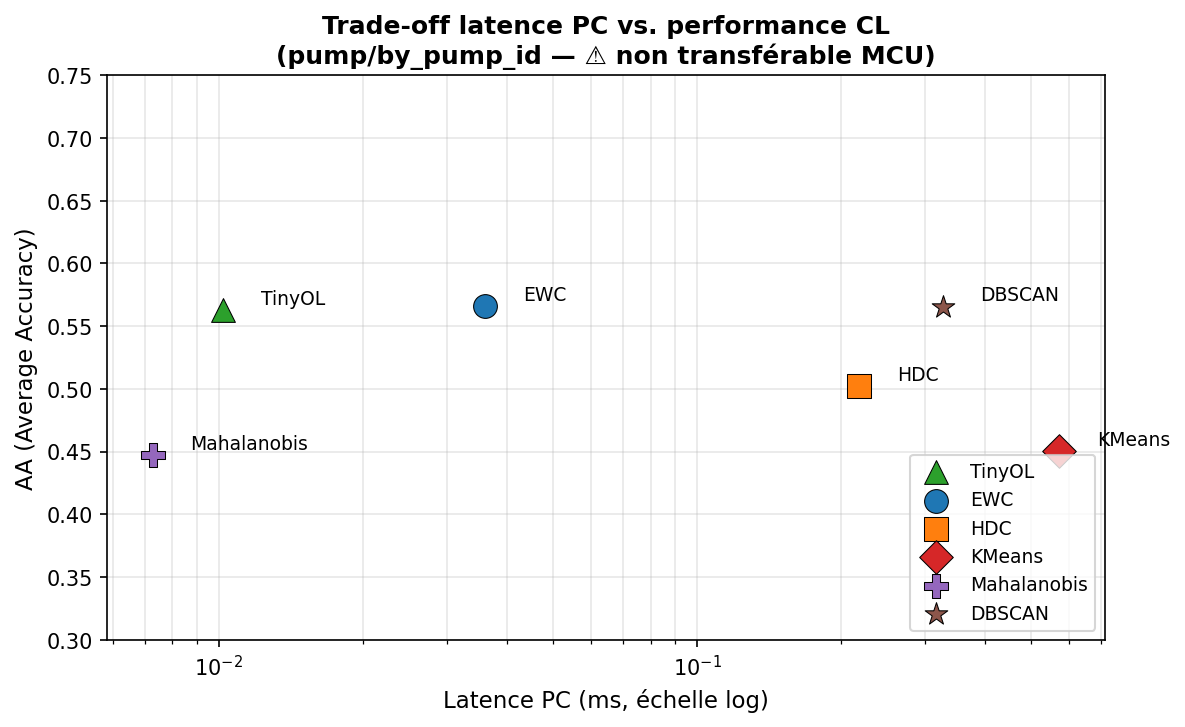

In [59]:
# Section 6c — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU.

LATENCY_BUDGET_MS = 100.0

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat if lat > 0 else 1e-4, acc, marker=marker, color=color, s=130, zorder=5,
               label=name, edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(max(lat, 1e-4), acc), xytext=(max(lat, 1e-4) * 1.2, acc + 0.005),
                fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(pump/by_pump_id — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

In [62]:
# Section 7 — Tableau comparatif complet (6 modèles)

header = "| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |"
sep    = "|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|"
print(header)
print(sep)
rows_md = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b = r["ram_peak_bytes"]
    ram_s = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_LIMIT else ''}"
    auroc = r["auroc_avg"]
    auroc_s = f"{auroc:.4f}" if isinstance(auroc, (int, float)) else "—"
    n_par = r["n_params"] if r["n_params"] else "—"
    macs_m = macs.get(model, 0)
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{auroc_s} | {ram_s} | {r['inference_latency_ms']:.5f} ms | {n_par} | {macs_m:,} |"
    )
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles CL (pump/by_pump_id)\n\n" +
                 "\n".join(rows_md)))

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.5629 | 0.0071 | -0.0030 | — | 5.6 Ko | 0.01022 ms | 1506 | 336 |
| EWC | 0.5658 | 0.0099 | -0.0099 | — | 1.1 Ko | 0.03605 ms | 1377 | 1,328 |
| HDC | 0.5024 | 0.0347 | -0.0044 | — | 14.2 Ko | 0.21829 ms | 2048 | 55,296 |
| KMeans | 0.4504 | 0.0099 | +0.0001 | 0.4985 | 5.6 Ko | 0.57246 ms | 50 | 50 |
| Mahalanobis | 0.4471 | 0.0150 | +0.0050 | 0.4953 | 2.0 Ko | 0.00728 ms | 650 | 650 |
| DBSCAN | 0.5656 | 0.0000 | +0.0000 | 0.4519 | 48.5 Ko | 0.32627 ms | 4950 | 4,950 |


### Tableau récapitulatif — 6 modèles CL (pump/by_pump_id)

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.5629 | 0.0071 | -0.0030 | — | 5.6 Ko | 0.01022 ms | 1506 | 336 |
| EWC | 0.5658 | 0.0099 | -0.0099 | — | 1.1 Ko | 0.03605 ms | 1377 | 1,328 |
| HDC | 0.5024 | 0.0347 | -0.0044 | — | 14.2 Ko | 0.21829 ms | 2048 | 55,296 |
| KMeans | 0.4504 | 0.0099 | +0.0001 | 0.4985 | 5.6 Ko | 0.57246 ms | 50 | 50 |
| Mahalanobis | 0.4471 | 0.0150 | +0.0050 | 0.4953 | 2.0 Ko | 0.00728 ms | 650 | 650 |
| DBSCAN | 0.5656 | 0.0000 | +0.0000 | 0.4519 | 48.5 Ko | 0.32627 ms | 4950 | 4,950 |

## Discussion — pump/by_pump_id (5 tâches)

### Pourquoi les performances approchent-elles du hasard (~0.50) ?
Le Dataset 1 (Large Industrial Pump Maintenance) présente un faible drift inter-Pump_ID :
les signatures de défaut sont similaires pour toutes les pompes (même type d'équipement,
mêmes capteurs). Les 25 features statistiques extraites par fenêtrage ne discriminent pas
suffisamment les états de pompes distinctes.

### Les scénarios granulaires (5 Pump_IDs) sont-ils plus difficiles que le chronologique (3 tâches) ?
À compléter après exécution. Hypothèse : difficulté similaire car le facteur limitant
est la qualité du feature engineering, pas le nombre de tâches.

### Quelles pompes sont structurellement plus difficiles à classifier ?
Voir le barplot `performance_by_pump_id_bar.png` — certains Pump_IDs peuvent avoir des
profils plus séparables si leurs conditions opératoires sont plus distinctes.

### Quel modèle a le meilleur ratio performance/RAM ?
À compléter après exécution. Référence by_equipment (Dataset 2) :
- EWC : AA=0.9824, RAM=1.1 Ko
- Mahalanobis : AA=0.9524, RAM=1.5 Ko

### Contrainte RAM STM32N6 (64 Ko)
À compléter après exécution — DBSCAN probablement > 64 Ko (FIXME gap2).

### Questions scientifiques ouvertes
- **FIXME(gap1)** : Les AA ≈ 0.50 sont-elles un résultat négatif intéressant (difficulté
  intrinsèque du dataset) ou une limite du feature engineering ? Contraster avec
  FEMTO PRONOSTIA (données plus diversifiées).
- **FIXME(gap2)** : DBSCAN dépasse probablement 64 Ko — piste buffer borné ou INT8.
- **TODO(arnaud)** : Les AA proches du hasard sont-elles à mettre en avant comme résultat
  négatif, ou à minimiser dans la présentation ?
- **TODO(arnaud)** : La comparaison chronologique (3 tâches) vs granulaire (5 tâches by_pump_id)
  est-elle à inclure dans ce notebook ou dans un notebook séparé ?
- **TODO(fred)** : Une accuracy de 0.50 sur 5 Pump_IDs est-elle acceptable si AF ≈ 0.01 ?
  Le client préfère-t-il la stabilité à la performance brute ?